# Lab 066 · Build TabICL: column memory, row identity and context prediction

[Lesson](../lessons/0066-tabicl-column-row-attention.html) · [Reference](../reference/0066-tabicl-column-row-attention.html) · [Author measurements](_verify_l066_v2_results.json) · [Reproduction](l066-reproduction.md)

**Skill:** implement and trace the complete three-stage pretrained model. **Five TODOs** drive the actual checkpoint forward and fresh context-size experiment. **CHECK** compares whole stages and preprocessing with the original source. **EXIT** binds your measured predictions to live code and weights. Read the complete architecture, then implement one operation at a time.

Default: all 768 diabetes rows, split seed 7, nested contexts 76/230/614 and 154 fixed queries. The author panel adds blood transfusion and WDBC, seeds 7/17/27. This is finite numeric one-view CPU inference, with a 108 MB original February checkpoint download; no synthetic pretraining occurs. Full TALENT benchmark and 500K memory experiment: NOT_RUN. Source license: [BSD 3-Clause](sources/l066-v2/LICENSE).

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Compress features before expensive labeled-row reasoning

<a href="../lessons/0064-tabpfn-v2.html">v2</a> retained feature tokens throughout its repeated blocks; <a href="../lessons/0065-tabpfn-query-embeddings.html">embedding extraction</a> showed why the stage and information boundary of a vector matter. TabICL deliberately separates representation construction from label-based inference. Column statistics inform cell embeddings, row attention compresses features, and only then do labels enter dataset-level attention.

### TabICL: build row representations before learning from labels

**Trace before reading:** Where does the feature axis disappear, and where do labels first enter?

<div style="max-width:100%;overflow-x:auto">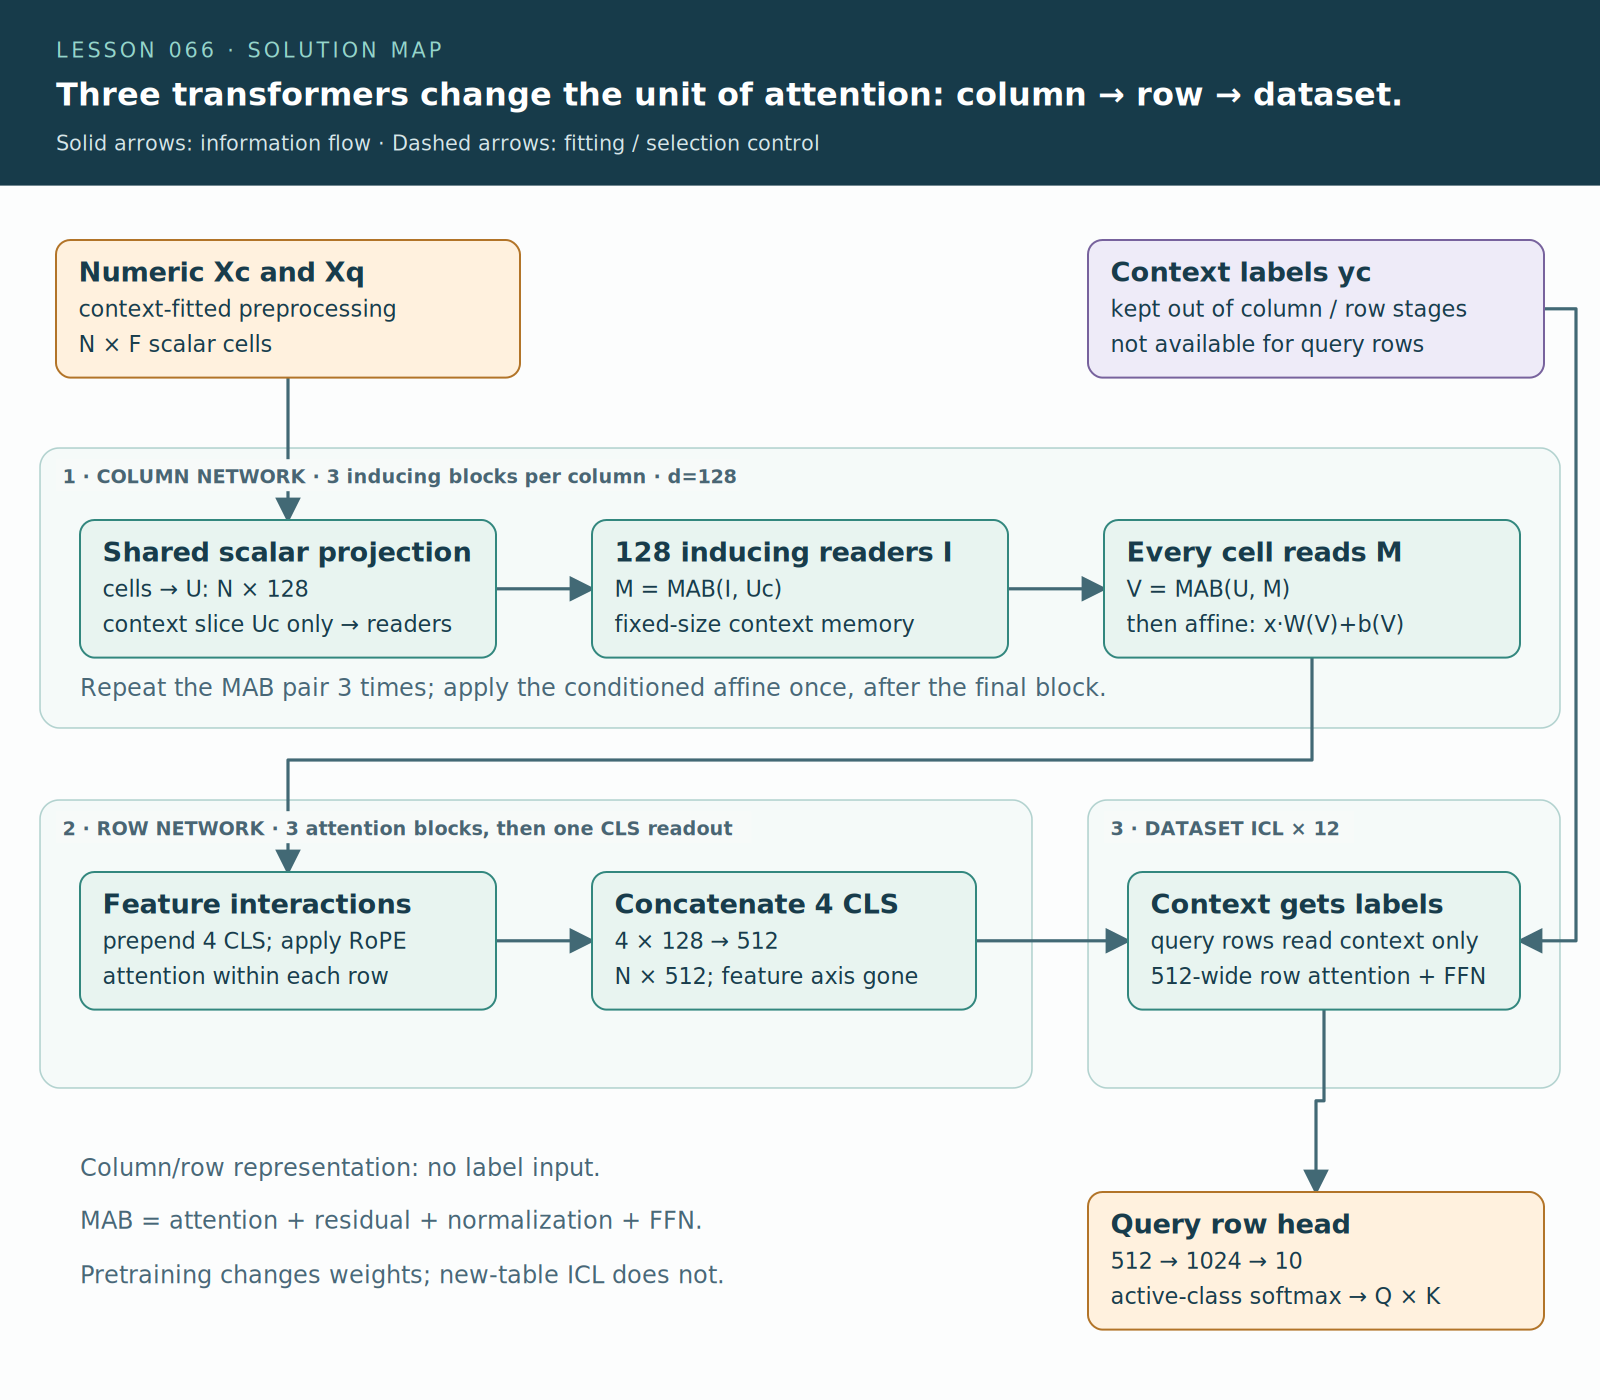</div>

**How the parts work together:** The row stage concatenates four 128-wide CLS outputs into one 512-wide row vector. Labels enter only after that compression, before dataset ICL. Column memory uses context values; the later dataset stage uses context row keys.

**Pictured scope:** Original February checkpoint, numeric single-view lesson path. Three column blocks, three row blocks, twelve ICL blocks. Hierarchical class extension and view ensembles are outside this pictured wrapper.

[Full-size vector diagram](../assets/solution-maps/0066-three-transformers.svg). Scroll on narrow screens to keep labels legible.

<details><summary>Text route: components and connections</summary><ol><li><strong>Numeric Xc and Xq</strong>: context-fitted preprocessing; N × F scalar cells. Connects to Shared scalar projection.</li><li><strong>Context labels yc</strong>: kept out of column / row stages; not available for query rows. Connects to Context gets labels.</li><li><strong>Shared scalar projection</strong>: cells → U: N × 128; context slice Uc only → readers. Connects to 128 inducing readers I.</li><li><strong>128 inducing readers I</strong>: M = MAB(I, Uc); fixed-size context memory. Connects to Every cell reads M.</li><li><strong>Every cell reads M</strong>: V = MAB(U, M); then affine: x·W(V)+b(V). Connects to Feature interactions.</li><li><strong>Feature interactions</strong>: prepend 4 CLS; apply RoPE; attention within each row. Connects to Concatenate 4 CLS.</li><li><strong>Concatenate 4 CLS</strong>: 4 × 128 → 512; N × 512; feature axis gone. Connects to Context gets labels.</li><li><strong>Context gets labels</strong>: query rows read context only; 512-wide row attention + FFN. Connects to Query row head.</li><li><strong>Query row head</strong>: 512 → 1024 → 10; active-class softmax → Q × K.</li></ol></details>

## Why collapse the feature axis before in-context learning?

Suppose you must predict outcomes for a new table whose columns did not exist during pretraining. A feature-specific tokenizer with a learned parameter for “age” cannot simply look up the meaning of an unnamed new column. A shared scalar tokenizer transfers across schemas, but the number 100 could be an ordinary income measurement, an extreme count, or a category code. The distribution of the other values supplies clues. TabICL first uses those clues to construct cell embeddings, combines each row's cells into one vector, and only then relates rows to their labels.

**Your outcome:** trace and implement a complete pretrained TabICL forward pass, verify its information boundaries against the released code, and measure how nested labeled contexts change prediction on the same query rows. This supports our relational mission by making the single-table baseline explainable. An efficient flat-table foundation model is a stronger baseline to beat; its columns and rows still contain no entity graph, foreign-key relation, or event-time availability rule.

Recall three prerequisites before continuing. **Attention** forms a weighted combination of value vectors, with weights obtained by normalizing query–key similarities. **In-context learning (ICL)** conditions fixed network weights on supplied examples; it does not update those weights for the new task. **A query row** is an example whose features are known and target is withheld. Training/context rows supply known targets. The word “training” can therefore name either expensive synthetic pretraining or the labeled context of a new task; distinguish them throughout this lesson.

The primary source is [Qu et al., original February 2025 paper, §§3–5 and Appendices B–E](https://arxiv.org/html/2502.05564v1). The active lab implements every pretrained layer of the original `tabicl-classifier-v1-0208.ckpt`, validated against release `tabicl==0.1.4`. The earlier lesson measured the later `v1.1-0506` checkpoint while showing only an untrained column skeleton. Those results remain historical. The revised experiment uses the original checkpoint and visible model throughout. Matching a checkpoint's computation is a narrower achievement than reproducing its pretraining or published benchmark.

## Model architecture: two phases, three transformers

Let **C** be the number of context rows, **Q** the number of query rows, **N=C+Q**, **F** the retained feature count, and **K** the observed class count. The paper uses different letters; these definitions stay fixed here. We omit a leading dataset batch dimension B in most diagrams. Context and query features are concatenated in that order; only the C context labels enter the model.

The numeric wrapper first removes columns that are constant in the context, then fits its scaling and outlier rules on that context. The column stage turns N×F scalars into N×F×128 cell embeddings. The row stage prepends four learned 128-dimensional CLS summary tokens to each row, processes F+4 tokens, and concatenates the four outputs into N×512 row representations. Finally, the ICL stage adds a learned label embedding to context rows, applies twelve attention blocks across rows, and decodes Q×K logits. A **logit** is an unnormalized class score; softmax turns these scores into probabilities summing to one.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"></div>

Complete original February checkpoint: numeric context-only preprocessing, three column ISABs, three RoPE row blocks, twelve ICL blocks and the full head. Labels enter only at ICL. All weights are frozen. [Full-size figure](figures/l066/architecture-v2.png).

**Connecting the ideas.** The complete block defines how a query reads a memory. The column stage uses that operator twice: learned inducing readers summarize context values, then every cell reads the summary. This gives shared scalar encoders column-specific behavior without using labels.

The full architecture is specific: **three induced column blocks, four attention heads and 128 inducing vectors per block; three row blocks with eight heads and four CLS tokens; twelve ICL blocks with four heads**. Column and row widths are 128; ICL width is 512. Every feed-forward hidden layer doubles its stage's width and uses GELU, a smooth activation. The checked checkpoint uses normalization before attention and feed-forward sublayers, with zero dropout at inference. It contains 27,051,658 trainable parameter entries plus eight fixed RoPE frequencies. These counts come from the loaded state, not a rounded marketing size.

There are two conceptual phases because column embedding and row interaction jointly construct the label-independent representation. There are three transformers because those two operations and ICL each have their own blocks. Label-independent does **not** mean context-independent: changing context feature values can change the row representations. Changing only context labels leaves the column and row stages fixed and changes the ICL stage. This separation is what later makes reuse across class-hierarchy subproblems possible. [Paper Figure 1, §§3.1–3.4](https://arxiv.org/html/2502.05564v1#S3).

The lab supports finite numeric arrays, one preprocessing/feature/class view, and two to ten classes. The full learned model is present; the source library is used only for validation. Categorical conversion, power-transform ensembles, hierarchical class extension, variable-width padded pretraining batches, and automatic CPU/disk offload are outside the measured wrapper. These omissions change the supported inference procedure, not the number of pretrained layers copied into the model.

Before entering the blocks, compare the previous architectures. Historical TabPFN v1 (Lesson 062) directly projects a whole row into a fixed-width token, then performs row ICL. TabPFN v2 (Lesson 064) retains grouped feature tokens plus a target token and repeatedly alternates within-row and across-row attention; labels enter the target-token stream before those repeated blocks. TabICL instead uses a context-aware, label-free column/row network to construct a single 512-coordinate row representation **before** its twelve ICL blocks. This removes the feature axis from the expensive later row attention, while making the quality of that earlier compression critical.

The distinction also sharpens Lesson 065's representation lesson. A TabICL **pre-ICL** row vector cannot contain its own supplied label, because no labels have entered yet. A final ICL context state can contain that label. Calling both “row embeddings” would conceal the information difference. These are architectural tradeoffs, not a proof that one family always wins.

## First make the attention block concrete

For one head, put the query vectors in A, keys in B, and values in V. A query has dₕ coordinates. Form the score matrix `S=A Bᵀ/√dₕ`, apply softmax separately across each row of S, and multiply the resulting weights by V. Each output is a mixture of eligible value vectors. Dividing by √dₕ controls how the typical dot-product scale changes with width; it is not division by the number of rows.

**Multihead attention** projects the input into several query/key/value coordinate systems and performs that calculation independently in each head. It concatenates head outputs and applies a learned output projection. In the column stage, four heads divide width 128 into 32 coordinates per head. Row attention has eight heads of 16 coordinates. Dataset attention has four heads of 128 coordinates. The notebook exposes the packed projection weights, the reshaping, the softmax and the output projection rather than calling the original attention package.

A multihead attention block, abbreviated **MAB**, also contains residual additions, normalization and a feed-forward network. In the checked pre-normalized release path, for query input q and memory input k:

`a = q + MHA(LN₁(q), LN₁(k), LN₁(k))`

`MAB(q,k) = a + Linear₂(GELU(Linear₁(LN₂(a))))`.

**Layer normalization**, LN, centers and rescales each token across its coordinates and then applies learned coordinate-wise scale and offset. It never computes a statistic across query rows. The residual connection preserves q as an explicit additive route. Consequently, a full MAB output is not constrained to lie in the convex hull of the memory vectors, even though an individual attention mixture is. The FFN acts on each token separately; row mixing occurs in attention. See [`MultiheadAttentionBlock.forward` in the pinned source](sources/l066-v2/tabicl/model/layers.py).

## Column stage: learned readers build a task-specific memory

Consider a single feature column. A shared linear layer first projects each scalar to a 128-dimensional token U. Sharing means that the same weights process all columns and future schemas; it does not force different columns to have the same output. Context values, and therefore the attention memory, differ across columns.

An **inducing vector** is a learned parameter that acts as a reader. It is neither a selected row ID nor a k-means centroid. In each column block, 128 inducing readers I first attend to only the C context tokens:

`M = MAB₁(I, U_context)` with shape 128×128.

All N cell tokens then read that memory:

`V = MAB₂(U, M)` with shapeN×128.

Three such blocks are applied in succession; each has its own inducing parameters and two complete MABs. The inducing parameters are fixed during inference, but the resulting memory M changes with the context. During pretraining, the final query prediction loss can backpropagate through both reads and update those parameters. At inference, the changing memory is conditioning, not an optimizer step. [Paper Eqs.3–6 and Figure 2](https://arxiv.org/html/2502.05564v1#S3.SS2).

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic one-head attention-only fixture with two inducing readers. Matrices expose both softmax operations; the query cannot write the memory. This omits full-block residuals/projections only for the arithmetic illustration." src="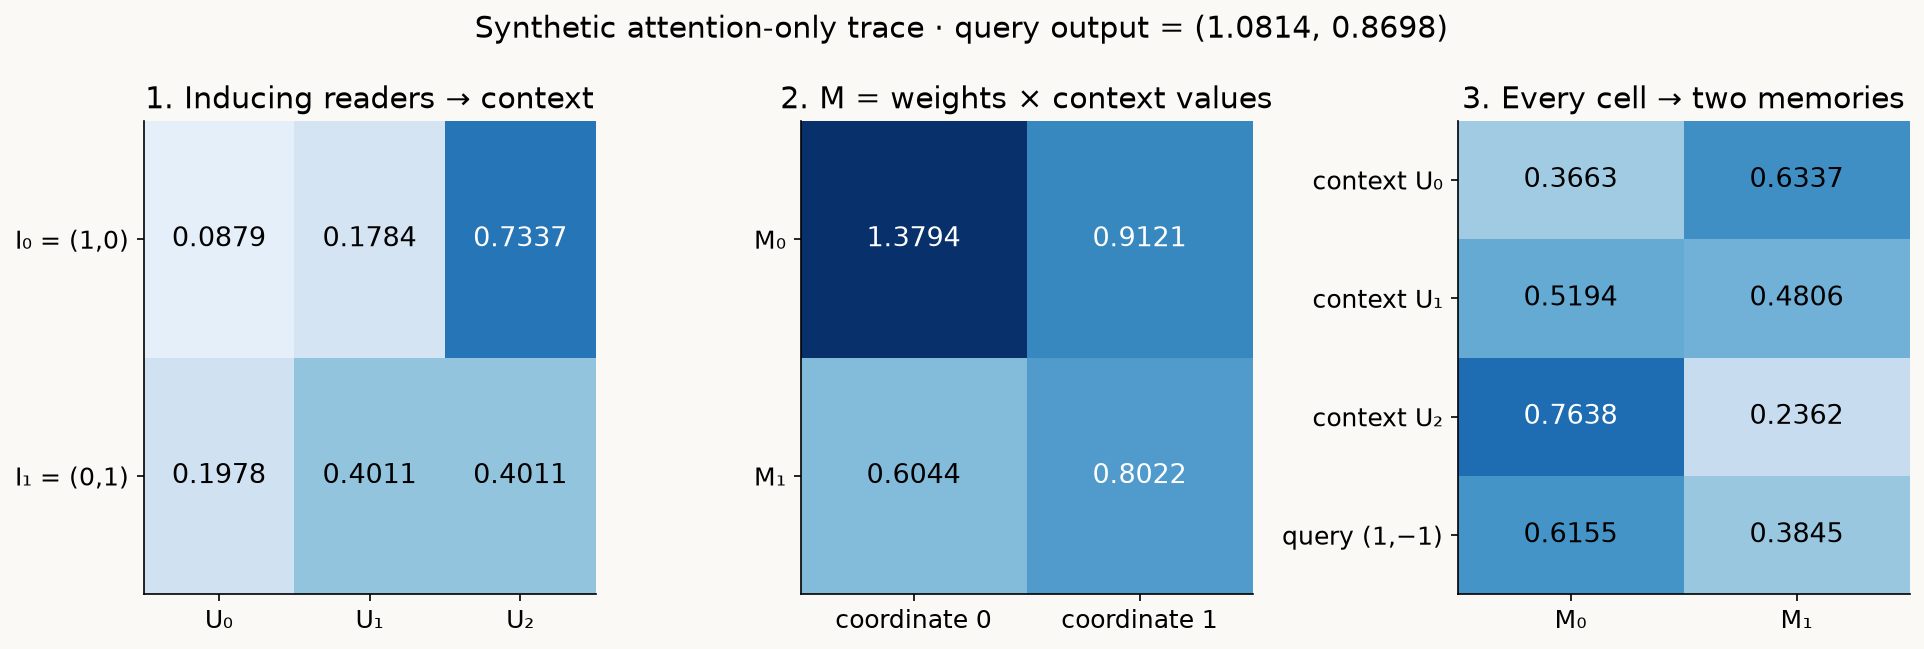" style="width:100%;min-width:1100px;max-width:none;height:auto"></div>

Synthetic one-head attention-only fixture with two inducing readers. Matrices expose both softmax operations; the query cannot write the memory. This omits full-block residuals/projections only for the arithmetic illustration. [Full-size figure](figures/l066/inducing-v2.png).

**Connecting the ideas.** Column processing has contextualized each cell but still leaves a feature axis. Row attention relates those feature states and collects them into four CLS outputs. Concatenating them creates the fixed-width row representation needed by the next stage.

The figure deliberately isolates the attention arithmetic: one head, identity projections, no residual or feed-forward transformations. Three context tokens are `(-1,0)`, `(0,1)` and `(2,1)`, and two inducing readers are `(1,0)` and `(0,1)`. The first reader's scores are `[-0.7071,0,1.4142]`; softmax gives weights `[0.0879,0.1784,0.7337]`. Its weighted memory is `(1.3794,0.9121)`. The second reader yields `(0.6044,0.8022)`. These vectors do not equal any supplied row.

A query token `(1,-1)` reads the two memories with weights approximately `[0.6155,0.3845]` and receives `(1.0814,0.8698)`. The three context readers produce different mixtures too. This shows why the output is not a single column mean broadcast everywhere. With exactly one inducing memory, every attention reader would receive that memory before the residual path; that special case cannot explain the richer 128-reader checkpoint.

**Predict before moving the control:** if an additional query becomes enormous, should M change? It cannot: query tokens never supply first-stage keys or values. The query can change its own second-stage mixture while existing rows remain fixed. By induction, that property survives all three column blocks. Each block's context outputs depend on earlier context outputs only. The paper's phrase that ISAB outputs “depend solely on training data” needs this precise reading: a particular query output also depends on that query's own features; it excludes other query rows. Allowing queries to write the memory would be a different, transductive procedure.

After the last column block, two distinct learned projections generate W and B. The release normalizes these generated vectors separately, then computes `E=x·W+B` coordinate by coordinate. Here x is the **wrapper-transformed scalar**, not an unscaled number such as raw income. The multiplication broadcasts that scalar across 128 coordinates. The function `conditional_affine` is live in every measured cell embedding; omitting the W/B normalizations can preserve all shapes while changing the checkpoint's behavior.

For a two-coordinate arithmetic fixture, x=2, W=(0.5,−1) and B=(0.1,0.3) produce E=(1.1,−1.7). This is a demonstration of the final affine step, not a learned model trace. The paper's Figure 3 projects summaries of 40,000 synthetic columns and finds structure associated with skewness and kurtosis. That is evidence of distribution-related information, not proof that each learned coordinate exactly computes a named statistic or causally identifies feature meaning.

## Row stage: retain feature identity while aggregating

The row transformer receives one row's F cell embeddings and four shared, learned CLS tokens. A CLS token is a trainable summary query with its own coordinates, not a class label. All F+4 tokens interact through each of the three row blocks. The four final CLS states are normalized individually and concatenated in their original order: four 128-wide vectors produce 512 coordinates. Averaging them would destroy the independent coordinate slots expected by the pretrained ICL weights.

Why introduce position into a table with no natural column order? Imagine two columns with identical distributions and a tokenizer that only sees those distributions. Without a positional identifier, a row containing feature tokens {a,b} and a row containing {b,a} present the same set to the CLS readers. Set aggregation cannot distinguish them, even if their labels differ. The paper illustrates this issue using balance-scale features with the same discrete value distribution. This is a mechanism argument about the representation; the accompanying t-SNE image is a visualization, not a numeric proof of downstream accuracy.

**Rotary positional embedding (RoPE)** rotates adjacent pairs of query/key coordinates before attention. For a pair `(u,v)` at token position p, let θ=p·ω. Its new coordinates are `(u cosθ−v sinθ, u sinθ+v cosθ)`. The rotation preserves the vector's length but can change its dot product with a vector at a different position. Because `R(p)ᵀR(q)=R(q−p)`, the score carries relative-position information. Values are not rotated in this path. [Paper §3.3 and Appendix C](https://arxiv.org/html/2502.05564v1#S3.SS3).

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic first adjacent pair with frequency one. The rotation preserves length while the relative-position dot product changes periodically; this is not a monotone distance-decay rule." src="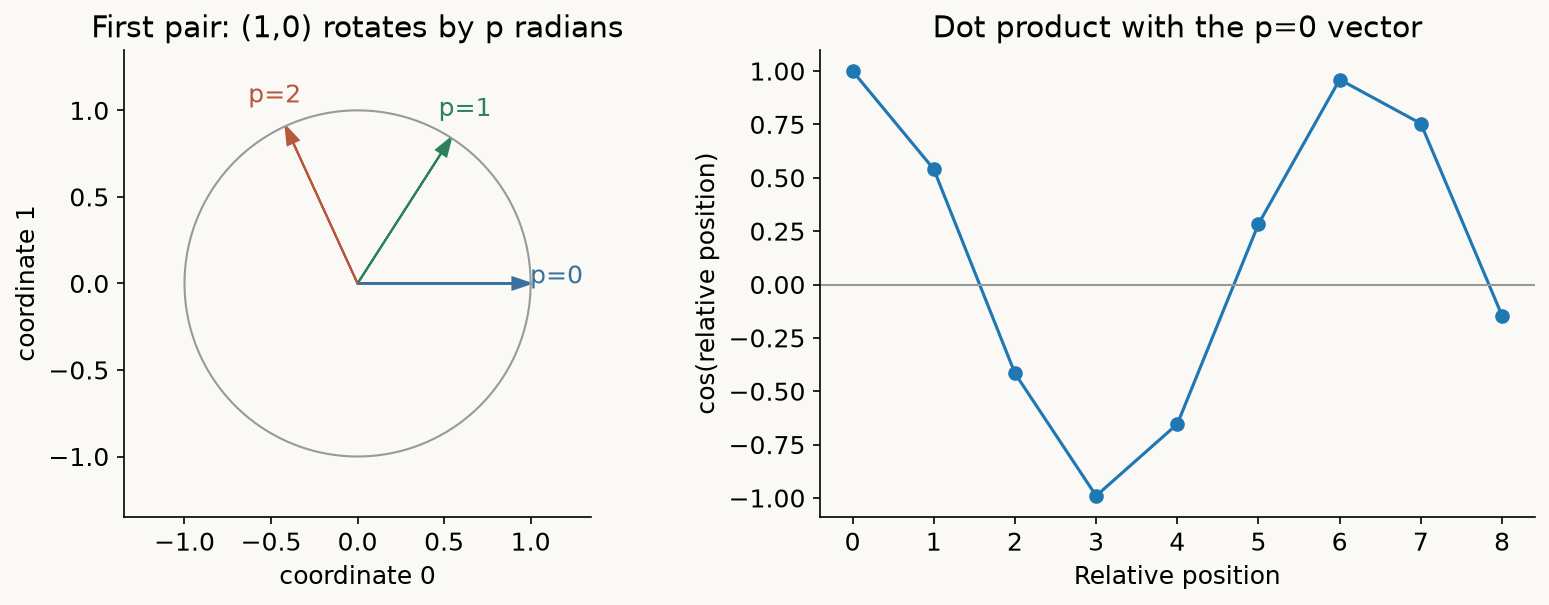" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Synthetic first adjacent pair with frequency one. The rotation preserves length while the relative-position dot product changes periodically; this is not a monotone distance-decay rule. [Full-size figure](figures/l066/rope-v2.png).

For the first frequency ω=1, take two unrotated query/key pairs both equal to `(1,0)`. At the same position their dot product is 1; separated by one position it is cos(1)≈0.5403; separated by two it is cos(2)≈−0.4161. A single pair need not decay monotonically with distance; the example becomes periodic. Do not turn “position affects the score” into an unconditional theorem that faraway columns receive lower attention.

The released row head has 16 coordinates and therefore eight adjacent pairs. Its frequencies are `ωᵢ=100000^(−2i/16)` for i=0,…,7. Positions include the four prepended CLS tokens: the first feature is position 4, not 0. The 100,000 base matches the model-specific choice in §3.3; Appendix C writes a generic 10,000 illustration. Changing the base or rotating halves instead of adjacent pairs produces a different computation even though shapes still match.

RoPE breaks exact single-view column-permutation invariance. Permuting whole columns consistently across context and query is a serialization intervention; swapping values within only a query row changes the input itself. These are different experiments. The paper averages multiple column/class/preprocessor views to reduce sensitivity to a particular ordering. Averaging a finite set of permutations approximates symmetry; it does not certify invariance under every permutation. The lab uses one fixed view so the mechanism remains inspectable and the computation bounded.

A separate fixed-weight source fixture makes the collapse mechanism measurable. The four context rows `(0,0),(0,1),(1,0),(1,1)` give both features the same distribution, with labels `[0,0,1,1]`. Queries `(0,1)` and `(1,0)` have class-1 probabilities about 0.000029 and 0.999969 with the released RoPE. Disabling only RoPE makes their row representations nearly identical and gives about 0.480839 and 0.480837. Changing context labels leaves these pre-ICL representations exactly unchanged. This is a forward intervention in already trained weights, **not** a retrained ablation or reproduction of paper Figure 4. [Executed source fixture](_symmetry_l066_results.json).

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Executed original-source fixed-weight intervention: context columns have identical marginals. Turning off RoPE nearly collapses swapped query representations. This is not a retrained ablation or reproduction of paper Figure 4." src="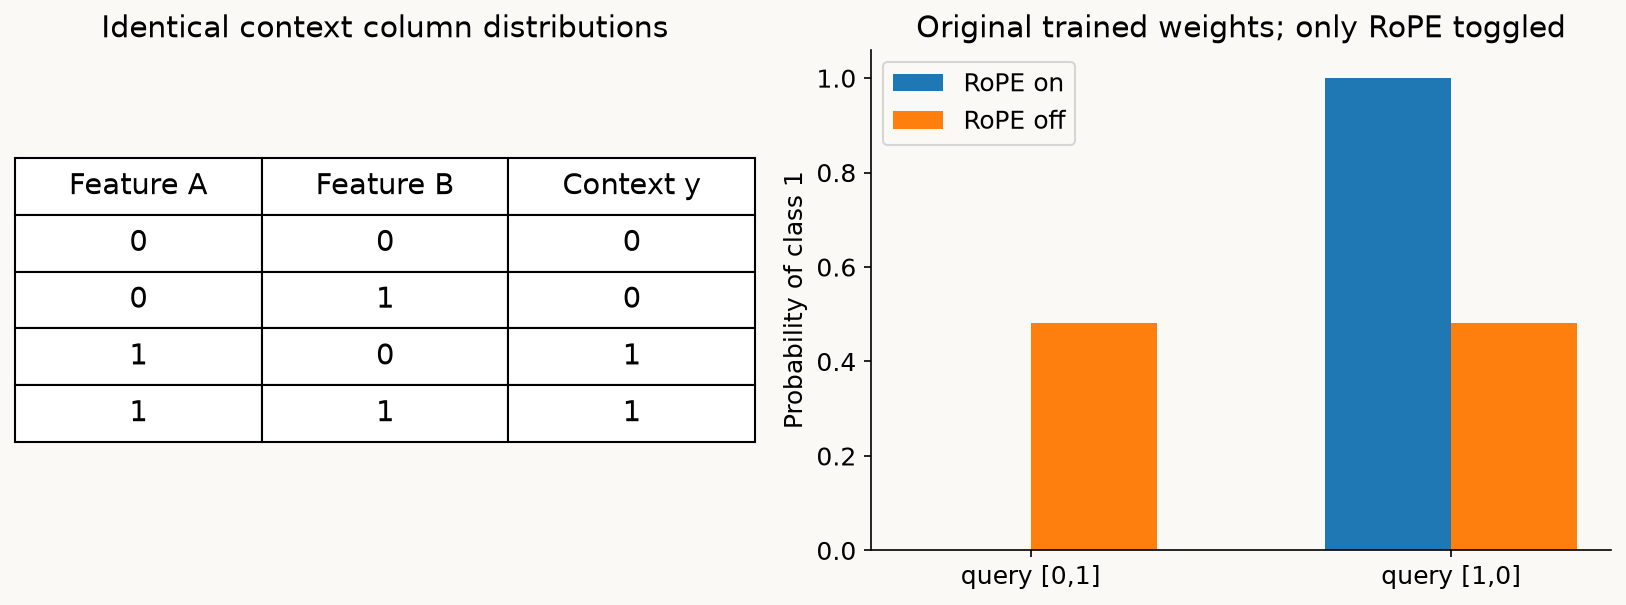" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Executed original-source fixed-weight intervention: context columns have identical marginals. Turning off RoPE nearly collapses swapped query representations. This is not a retrained ablation or reproduction of paper Figure 4. [Full-size figure](figures/l066/symmetry-v2.png).

**Connecting the ideas.** The feature axis has now disappeared into one row vector. This is the first point where labels are added. Dataset attention can therefore spend its work on relations between labeled examples rather than repeating full feature-axis reasoning.

## Dataset stage: labels enter here, queries read only context

The 512-dimensional row representation H was computed without labels. For each context label y, the release creates a 10-way one-hot vector, applies a learned linear map to 512 coordinates, and adds that label embedding to H. Even a two-class dataset uses the learned 10-input label encoder. Query rows receive no label embedding. No placeholder query target is passed to this model.

Each of twelve ICL blocks allows every context row to attend to all C context rows, including itself. Every query may attend to those same C rows and to no query rows, including itself as a key. Its own representation still travels through the residual path and serves as its query vector. Thus “no query self-attention” does not mean “the prediction ignores the query features.”

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic C=3, Q=2 role mask for every ICL block, including all context self-keys and no query keys. Query features still supply queries and residual states." src="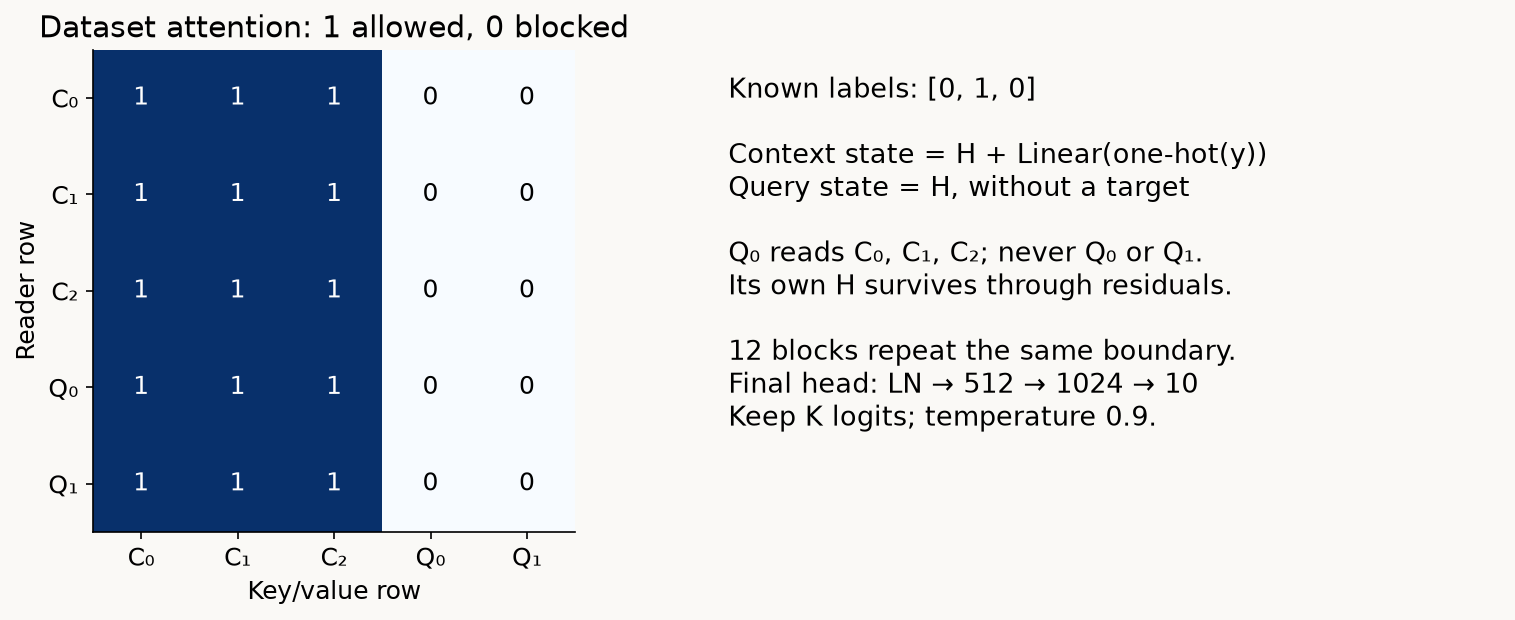" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Synthetic C=3, Q=2 role mask for every ICL block, including all context self-keys and no query keys. Query features still supply queries and residual states. [Full-size figure](figures/l066/roles-v2.png).

**Connecting the ideas.** Separating stages changes where computation is spent; it does not remove attention costs. Count column memory construction, row compression and dataset attention separately before interpreting speed or the effect of more context.

The mask can be implemented more directly than constructing an N×N Boolean matrix: project Q for all N readers, but restrict K and V to the first C rows. The resulting score tensor is N×C per head. That restriction works for both context and query readers. It is **not** a language-model causal mask: context row 0 can read context rowC−1. It is also not enough to mask only the final block; allowing query information into earlier context states would open a path back to other queries.

After the final block, the source applies a 512-coordinate LayerNorm and the complete head `Linear(512,1024) → GELU → Linear(1024,10)`. Keep the first K observed-class logits and apply softmax after division by temperature 0.9. If two logits are(0,0.9), their scaled difference is 1 and the second class probability is 0.7311. Temperature is a fixed release setting here; the test labels do not tune it. Better accuracy and better log loss can disagree because log loss depends on probability confidence as well as the largest-probability class.

This architecture gives a useful three-part isolation argument. Column memories use context feature rows only; row attention stays inside each row; ICL keys use context states only. Therefore changing or appending an unrelated query cannot change an existing query's mathematical result under this wrapper. Small floating-point differences can arise when shapes change numerical kernels, so the checker uses explicit tolerances. Separately, changing a context label should affect ICL predictions while preserving the first two stages. Both directions are necessary: isolation plus sensitivity demonstrates a functioning information boundary.

## The wrapper is part of the prediction procedure

A correct attention mask cannot rescue preprocessing fitted on the full table. The supported release path receives a finite numeric array and uses the context to identify nonconstant features. Query variability cannot rescue a constant context column. It then computes a population standard deviation plus 10⁻⁶ for each retained feature, subtracts the context mean, scales, and clips to[−100,100]. The same parameters transform the query.

Next comes a less familiar two-pass outlier rule. Compute the sample mean and sample standard deviation of the scaled context; exclude values beyond four standard deviations **only when recomputing those statistics**; then form new lower and upper bounds. Transformation softens extreme values using logarithms. It does not delete the observations from the context. The code applies the lower operation first and computes the upper operation from its result, so reversing the two lines can change the answer. The worked CHECK includes an extreme context value and a constant column to detect this path. [`PreprocessingPipeline`, `OutlierRemover`, `CustomStandardScaler`](sources/l066-v2/tabicl/sklearn/preprocessing.py).

The name `normalization_method='none'` is potentially misleading: it skips the **optional second** normalization such as Yeo–Johnson power transformation. Initial standardization and outlier processing still run. In a one-estimator release wrapper, the default method order selects this none view and performs no feature or class shift. Our supported wrapper explicitly names those choices, compares transformed arrays with the source, and verifies final probabilities.

Missing values, categorical strings and all-constant contexts receive explicit rejection in this lab rather than an invented embedding policy. The official DataFrame conversion path has additional type-specific preprocessing; it is not certified by a finite-array check. More generally, the “full model” and “full wrapper” are different scope claims. Here all pretrained layers are implemented, while the wrapper intentionally supports the declared numeric single-view path.

The optional power view shows why this scope matters. In an executed original-source fixture, appending two extreme queries triggers a power-transform error and a fallback that clips the **whole query batch** to context extrema. An existing query's class-1 probability changes from 0.977911 to 0.999381, despite unchanged context and model weights. The none-view control keeps its encoded input identical, with only a 2.38×10⁻⁷ numerical probability difference. This exposes wrapper coupling, not a failure of the model's context-only attention boundary. The behavior was checked under the recorded scikit-learn 1.9.0 runtime; it is not an assertion about every library version. [Counterexample and exact inputs](_query_coupling_l066_results.json).

## Count the remaining cost before interpreting timing

For one table, let m=128 inducing vectors and L denote the number of blocks in the relevant stage. Count conceptual attention-score elements, including every head. Column attention uses `3·4·F·m·(C+N)`: each block forms m×C scores to write its memory and N×m scores to read it. Row attention uses `3·8·N·(F+4)²`. Dataset attention uses `12·4·N·C`, or `12·4·(C²+QC)`. Projection and feed-forward work are additional.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Conceptual attention-score counts across all blocks/heads, with Q=100 and F=8 fixed. These are arithmetic counts, not GPU peak-memory estimates or measurements." src="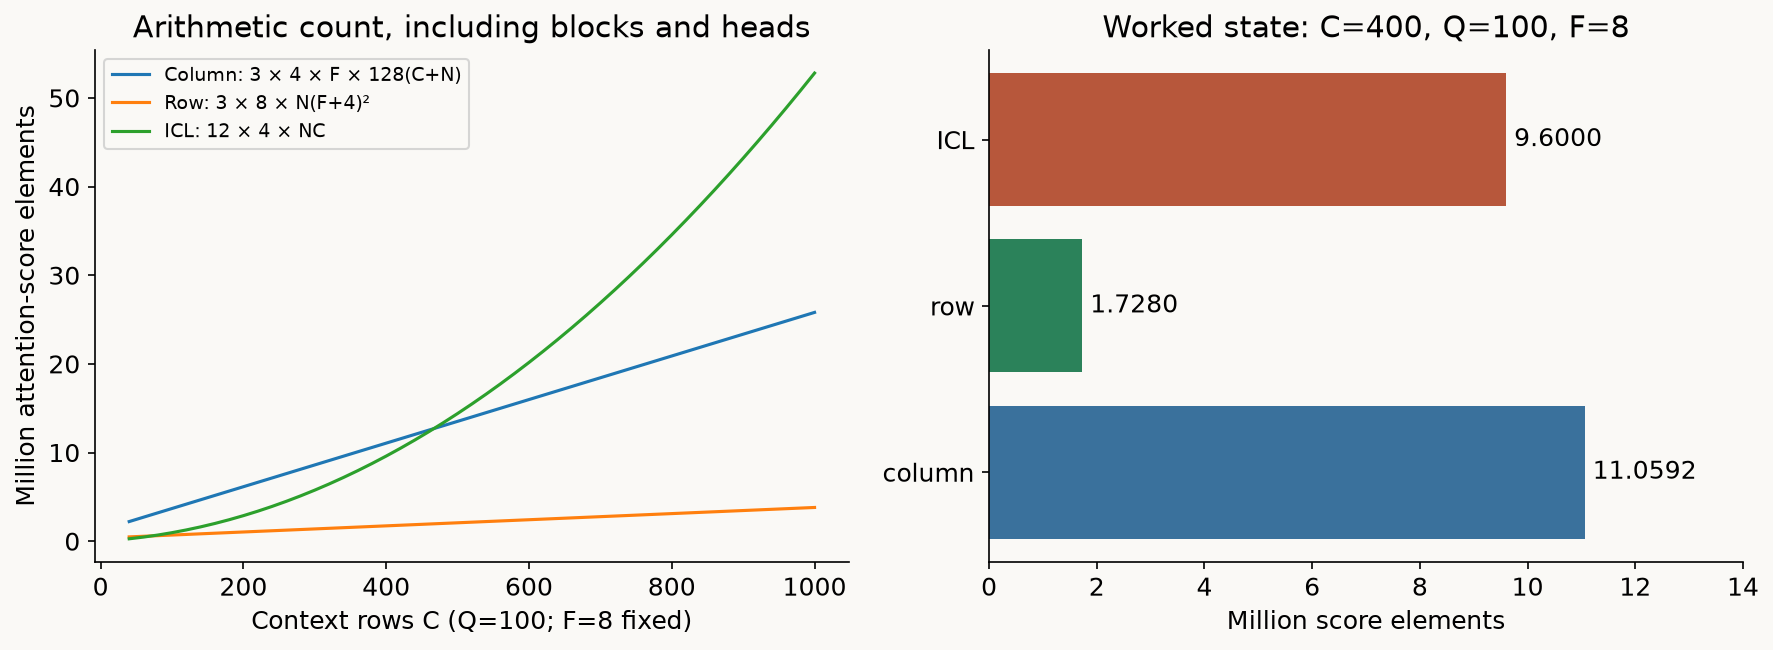" style="width:100%;min-width:750px;max-width:none;height:auto"></div>

Conceptual attention-score counts across all blocks/heads, with Q=100 and F=8 fixed. These are arithmetic counts, not GPU peak-memory estimates or measurements. [Full-size figure](figures/l066/cost-v2.png).

With C=400, Q=100 and F=8, these counts are 11,059,200 for the column stage, 1,728,000 for the row stage, and 9,600,000 for dataset ICL. Holding Q and F fixed while doubling C makes the ICL term grow from 9.6million to 34.56million. The inducing column computation grows linearly in row count for fixed m; the complete system retains a context-quadratic ICL term. For small contexts, 128 inducing readers can even cost more score elements than direct context attention in that one column. The design targets a favorable regime, not an algebraic win at every C.

These are operation counts, not a peak-memory estimator. Our visible `attention_mix` materializes its score matrix. The paper's efficient implementation uses FlashAttention, stage-specific batching, and activation offload. FlashAttention can avoid storing a full quadratic score matrix while still performing quadratic attention work. Reducing memory complexity does not automatically reduce arithmetic complexity.

Appendix D.2 changes the batching unit by stage: columns for the column encoder, rows for row interaction, and tables for ICL. Its memory predictor is fitted on an A100 and guides those batch sizes. In the 500,000-row, 500-feature example, 80% of rows are context and 20% queries; the appendix reports less than 14 GB GPU memory but roughly 120 GB CPU memory before optional disk offload. That is a specific demonstrated system configuration, not a promise that our eager CPU implementation fits the same table or that a 14 GB GPU alone suffices. The 500K experiment remains **NOT_RUN** here.

## What pretraining taught the fixed weights

The architecture explains information flow; its learned weights come from a separate synthetic-training procedure. The paper mixes 70% neural SCM tasks with 30% tree-based SCM tasks. An SCM is a directed acyclic dependency graph in which a child variable is a function of its parents plus noise. The tree construction fits XGBoost models to random Gaussian targets at graph layers, then uses their predictions as child values. It is not supervised training on real task labels and not simply attaching a tree to the final target. Appendix B also broadens nonlinearities, including random Fourier-feature activation functions whose coefficients define sampled functions. [§4.1 and Appendix B](https://arxiv.org/html/2502.05564v1#S4.SS1).

The curriculum begins with 1024-row tasks for 100,000 optimizer steps, proceeds through 2000 steps with task sizes log-uniformly sampled between 1K and 40K, and ends with 50 steps on 40K–60K rows while freezing the embedding stages and training only ICL. Each optimizer step comprises 512 synthetic datasets; microbatches and gradient accumulation make that effective batch possible. Appendix D.1 specifies Adam, gradient-norm clipping at 1, and distinct learning-rate schedules by stage. Three 40 GB A100s ran for about two weeks. A forward-pass lab copies the outcome of that training; it does not regenerate it.

For more than ten classes, the paper constructs a classification hierarchy. A node predicts a class group; a descendant predicts a finer group or class. A class's probability multiplies its conditional probabilities along the route. For example, a parent probability 0.6 and within-group class probability 0.25 yield 0.15 for that class. Because the row embeddings were computed without labels, subproblems can reuse them while changing context label encodings in ICL. The lab rejects K>10; describing this strategy does not establish an executed hierarchy implementation.

## Fresh experiment: additional context, fixed query rows

**Commit a prediction first:** should every increase in C improve both accuracy and log loss on every fixed query set? More labels may help, but new examples also change the learned conditioning problem, the column distribution summaries and wrapper statistics. Finite samples and a fixed synthetic prior offer no monotonicity theorem.

The author experiment uses all rows of three small numeric datasets: diabetes 768×8, blood transfusion 748×4, and WDBC 569×30. These are complete local datasets, not a five-hundred-row sample of a large benchmark. For split seeds 7,17 and 27, a stratified split reserves 20% as queries. A predeclared label-blind permutation of the remaining 80% defines nested context prefixes at 12.5%,37.5% and 100%. The three sizes are 76/230/614 for diabetes, 74/224/598 for blood transfusion, and 56/170/455 for WDBC. Query IDs stay fixed across context sizes within each split.

No model is fitted or selected using query labels. The network and temperature remain fixed; wrapper statistics refit on each legal context. This intervention therefore measures the complete supported system's response to additional context, including representation and preprocessing changes. It does not isolate label count while holding every representation fixed. Record preprocessing, column, row and ICL wall times separately, excluding checkpoint load and source verification. CPU threads are fixed to one. Small shared-workspace wall times are diagnostics of this run, not a benchmark speedup against another model.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Fresh original-checkpoint measurements on three complete small datasets and three split seeds. Connected points share fixed query IDs; other context prefixes are nested. These are individual runs, not confidence bands." src="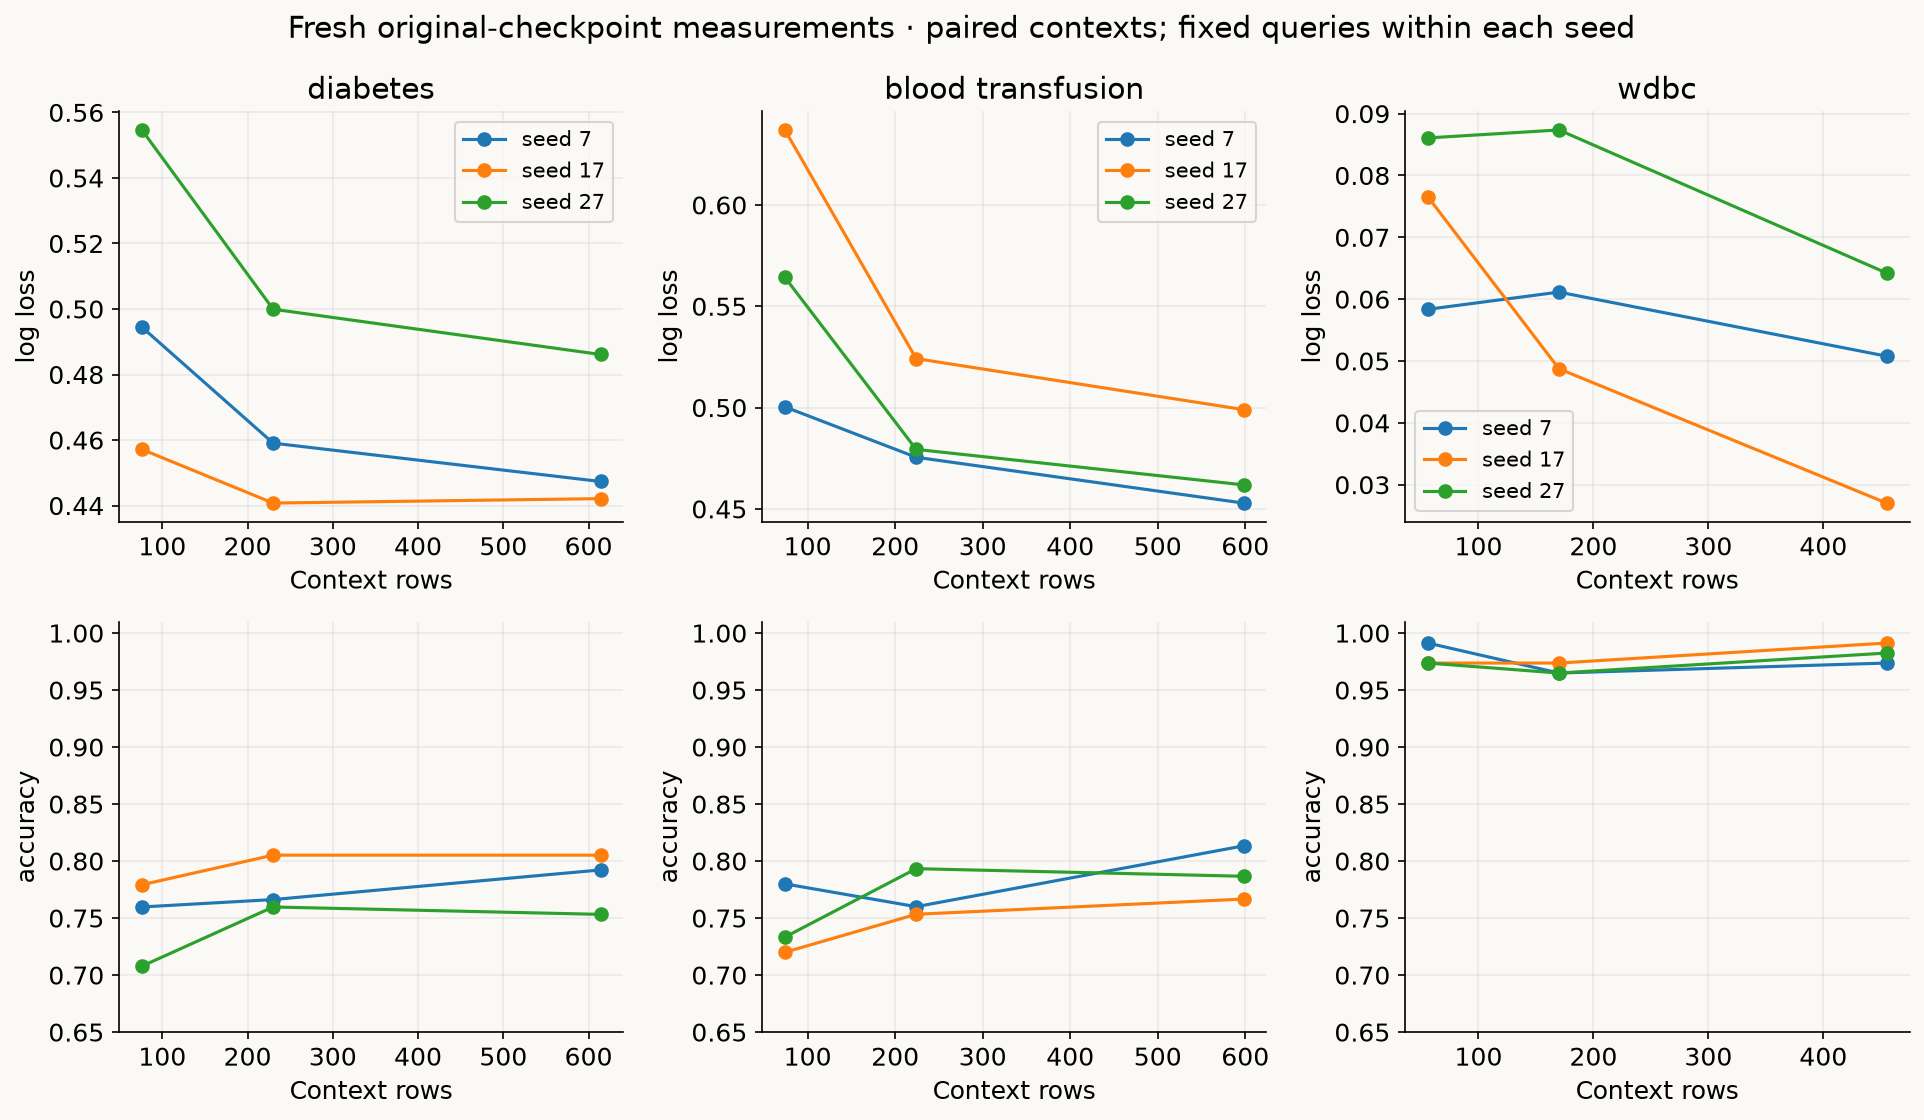" style="width:100%;min-width:1100px;max-width:none;height:auto"></div>

Fresh original-checkpoint measurements on three complete small datasets and three split seeds. Connected points share fixed query IDs; other context prefixes are nested. These are individual runs, not confidence bands. [Full-size figure](figures/l066/results-v2.png).

The actual mean log losses (small → middle → full context) are **0.5021 → 0.4666 → 0.4585** for diabetes, **0.5672 → 0.4930 → 0.4713** for blood transfusion, and **0.0737 → 0.0657 → 0.0473** for WDBC. All three mean losses improve, but accuracy is not monotone: WDBC moves from 0.9795 to 0.9678 to 0.9825. On WDBC seed 27, middle-context loss also rises slightly above small-context loss. That one exception is enough to reject the prediction that every context increase must improve every metric.

| Dataset | Context rows | Log loss mean ± SD | Accuracy mean ± SD |
|---|---:|---:|---:|
| diabetes | 76 | 0.5021 ± 0.0492 | 0.7489 ± 0.0369 |
| diabetes | 230 | 0.4666 ± 0.0303 | 0.7771 ± 0.0246 |
| diabetes | 614 | 0.4585 ± 0.0240 | 0.7835 ± 0.0270 |
| blood_transfusion | 74 | 0.5672 ± 0.0684 | 0.7444 ± 0.0315 |
| blood_transfusion | 224 | 0.4930 ± 0.0270 | 0.7689 ± 0.0214 |
| blood_transfusion | 598 | 0.4713 ± 0.0245 | 0.7889 ± 0.0234 |
| wdbc | 56 | 0.0737 ± 0.0141 | 0.9795 ± 0.0101 |
| wdbc | 170 | 0.0657 ± 0.0197 | 0.9678 ± 0.0051 |
| wdbc | 455 | 0.0473 ± 0.0188 | 0.9825 ± 0.0088 |

Author-reference results, three seeds per cell. SD is sample standard deviation, not a confidence interval.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Exploratory dataset-balanced loss ranks and measured stage CPU seconds. Seeds are averaged within each of three convenience datasets; the paper speedup and full benchmark remain untested." src="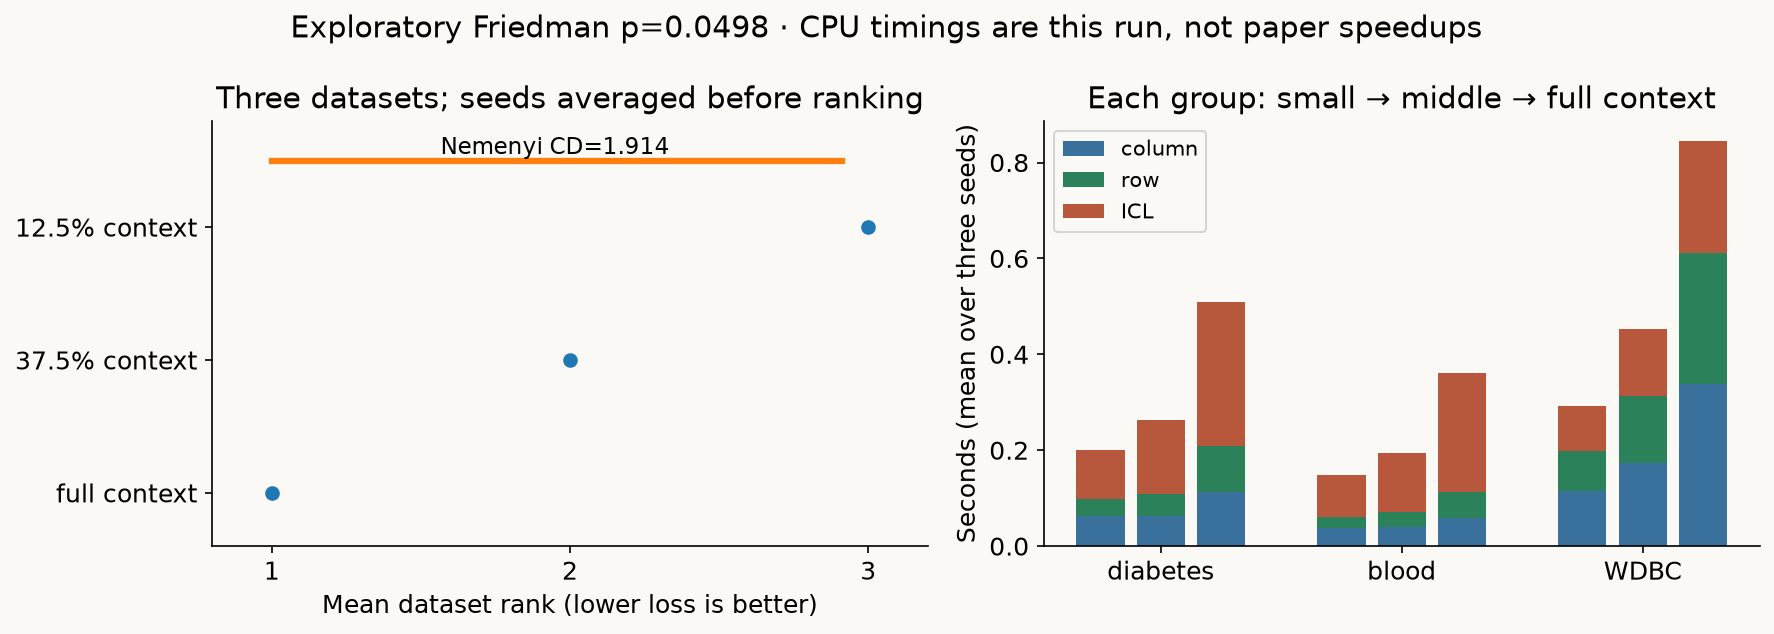" style="width:100%;min-width:850px;max-width:none;height:auto"></div>

Exploratory dataset-balanced loss ranks and measured stage CPU seconds. Seeds are averaged within each of three convenience datasets; the paper speedup and full benchmark remain untested. [Full-size figure](figures/l066/ranks-v2.png).

The full-minus-small loss differences average −0.0436, −0.0960 and −0.0263. Their conditional t 95 intervals are [−0.1104, 0.0233], [−0.2092, 0.0173] and [−0.0793, 0.0266]; all include zero. Mean loss ranks are 3, 2 and 1 for small, middle and full context, with exploratory Friedman p=0.0498 and Nemenyi CD=1.914. Enumerating all 6³=216 within-dataset rank permutations gives exact p=6/216≈0.0278 under an exchangeable-method-ranks null. That null treats each dataset as independent and all context-size rank assignments as equally likely; it does not make these convenience datasets representative or these overlapping seed splits independent. The asymptotic Friedman test uses a chi-square approximation, which is especially fragile with only three datasets. Both tests address this small rank panel; the barely sub-0.05 p-value does not override the small evidence base or create a universal law. The complete measured stages took 9.81 seconds in this CPU run, excluding load/checks. Larger WDBC feature count makes its column/row costs visibly important. [Prediction reconstruction and statistics](_analysis_l066_v2_results.json).

Read connected points as paired context-size interventions on the same split. Each dataset has three overlapping random splits, not three independent datasets. Mean and sample standard deviation across those seeds describe conditional variability; a t interval with only two degrees of freedom is fragile. When we rank the three context sizes, we first average loss within each dataset and then weight the three datasets equally. A Friedman/Nemenyi summary on just three datasets is exploratory. A green cell or a lower mean does not support a universal “larger context always wins” conclusion.

The published study analyzes 188 datasets with at most ten classes, with 132 small and 56 large datasets in Appendix E; its wider 200-classification-task roster adds 12 many-class tasks. The introduction's 55-large wording differs from that appendix count. Its 64/16/20 split, 32-view ensembles, power-transform views, task roster and hardware differ from our 80/20 single-view experiment. Competitor time accounting also differs: Figure 5 approximates some tuning times from best-configuration training time multiplied by 100. Reported speed and rank statements belong to that protocol. [§5 and Appendix E](https://arxiv.org/html/2502.05564v1#S5).

The paper reports no statistically significant overall difference between TabICL and TabPFN v2 in its supported-class rank comparison. Failure to reject a difference is not proof of equivalence. Lower log loss is evidence about the probability score; it does not by itself establish calibration in every subgroup or under distribution shift. Our local context experiment contains no TabPFN or tree arm and cannot independently reproduce those family comparisons.

## From a passing CHECK to a defensible EXIT

The five live TODOs implement attention mixing, context-only keys, adjacent-pair RoPE, two-stage inducing memory and the final conditioned affine map. Their functions are called by the visible pretrained model and by the measured experiment. The reference checks copy the exact original weights, compare complete column and row outputs and final logits across multiple fixtures, then compare preprocessing and wrapper probabilities. They also test the query boundary, the coordinate convention and sensitivity to legal context changes.

An EXIT binds the actual live functions and model methods, their nested-code dependencies, configuration, library versions, loader and checkpoint weights. The source-check identity, experiment identity and EXIT identity must agree in the same execution namespace. Editing a helper called inside a generator expression or changing weights after measurement must reject stale evidence. A notebook compilation identity can differ from the module compilation identity; numerical source parity is checked in both rather than relabeling one hash as the other.

Submit the measured artifact and explain one paired result, one isolation check and one unrun paper claim. Then do a cold teach-back: why are labels absent from the first two stages, why does query isolation need three boundaries, and why does the inducing bottleneck not make the whole model linear? Bring a failed prediction or unclear step to the tutor. A correctly executed notebook is evidence of runnable work; mastery is assessed from your explanation and transfer to a new case.

The next step repeats the same visible model on all three datasets and seeds through the gated closer cell or the versioned local operator. It is a broader local replication. Original synthetic pretraining, full TALENT 32-view evaluation, many-class hierarchy evaluation and 500K resource measurement remain **NOT_RUN**. Lesson 067 then asks what changes when pretrained parameters themselves are adapted rather than merely conditioned on a larger context.

## PROVIDED · Environment and scope
The model, preprocessing and experiment definitions below execute in this notebook's namespace. Your TODOs are global dependencies of these live model methods. The reference package runs separately and contributes only comparison outputs. Data loading, plotting and metric libraries are peripheral support; the pretrained forward pass is visible.

In [ ]:
# PROVIDED — imports and bounded CPU runtime
import os,sys,hashlib,importlib.metadata,inspect,json,math,time,types,urllib.request
from pathlib import Path
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from IPython.display import display
import pandas as pd
for directory in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (directory/'relkit').is_dir():ROOT=directory.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run bootstrap or start Jupyter in labs')
torch.set_num_threads(1)
output=Path(os.environ.get('L066_OUTPUT',str(ROOT/'data/cache/l066-student')))
output.mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED — immutable checkpoint and declared numeric procedure
CHECKPOINT_SHA='f5bae1d31181a1bb4ab8e97d2a5e62a504e856f23b4ea62c7fcc2f8eec4995b6'
CHECKPOINT_URL='https://huggingface.co/jingang/TabICL-clf/resolve/eaf789a9b25ee8486d6f48997ba076f850bbc30b/tabicl-classifier-v1-0208.ckpt'
CHECKPOINT_FILE='tabicl-v1-0208.ckpt'
MODEL_CONFIG={'max_classes': 10, 'embed_dim': 128, 'col_num_blocks': 3, 'col_nhead': 4, 'col_num_inds': 128, 'row_num_blocks': 3, 'row_nhead': 8, 'row_num_cls': 4, 'row_rope_base': 100000, 'icl_num_blocks': 12, 'icl_nhead': 4, 'ff_factor': 2, 'dropout': 0.0, 'activation': 'gelu', 'norm_first': True}
PROTOCOL={'temperature': 0.9, 'normalization': 'none', 'views': 1, 'query_fraction': 0.2, 'context_fractions': [0.125, 0.375, 1.0], 'float': 'float32', 'outlier_threshold': 4.0, 'query_keys': False, 'embedding_with_query': False}
PRESETS66={'smoke': {'datasets': ['diabetes'], 'seeds': [7]}, 'lab': {'datasets': ['diabetes'], 'seeds': [7]}, 'closer': {'datasets': ['diabetes', 'blood_transfusion', 'wdbc'], 'seeds': [7, 17, 27]}}

## TODO 1 · Mix values using scaled query–key scores

**Goal:** Return attention outputs with the same reader axes as q; normalize over keys and reject empty memory.

**Why:** The head width controls score scaling; row count does not.

**Hint boundary:** Trace the attention-only example. Preserve arbitrary leading batch/head axes.

In [ ]:
# TODO — attention_mix
def attention_mix(q,k,v):
    raise NotImplementedError("Implement this live TabICL operation")

In [ ]:
# CHECK — attention_mix
q=torch.tensor([[1.,0.],[0.,1.]])
k=torch.tensor([[-1.,0.],[0.,1.],[2.,1.]])
a=attention_mix(q,k,k)
torch.testing.assert_close(a,torch.tensor([[1.3794,.9121],[.6044,.8022]]),atol=6e-5,rtol=0)
assert attention_mix(q[None,None],k[None,None],k[None,None]).shape==(1,1,2,2)
print("CHECK passed: attention_mix")

## TODO 2 · Enforce the dataset information boundary

**Goal:** Return the context prefix of keys and values while retaining all other axes; reject invalid boundaries.

**Why:** Both context and query readers use this prefix in every ICL block.

**Hint boundary:** The sequence axis is second from last after head splitting.

In [ ]:
# TODO — context_keys
def context_keys(k,v,n_context):
    raise NotImplementedError("Implement this live TabICL operation")

In [ ]:
# CHECK — context_keys
k=torch.arange(2*3*5*4.).reshape(2,3,5,4);v=k+1000
a,b=context_keys(k,v,3)
assert torch.equal(a,k[:,:,:3]) and torch.equal(b,v[:,:,:3])
assert a.shape==(2,3,3,4)
print("CHECK passed: context_keys")

## TODO 3 · Rotate adjacent head-coordinate pairs

**Goal:** Rotate every adjacent pair at its sequence position using the supplied frequency vector; preserve dtype and length.

**Why:** Rotating halves or omitting CLS positions changes the pretrained score computation.

**Hint boundary:** Construct the perpendicular pair and combine sine/cosine terms; do not rotate value vectors.

In [ ]:
# TODO — rotary_pairs
def rotary_pairs(x,freqs):
    raise NotImplementedError("Implement this live TabICL operation")

In [ ]:
# CHECK — rotary_pairs
x=torch.tensor([[[1.,0.,1.,0.],[1.,0.,1.,0.],[1.,0.,1.,0.]]]);freq=torch.tensor([1.,.1])
a=rotary_pairs(x,freq)
torch.testing.assert_close(a[0,1],torch.tensor([math.cos(1),math.sin(1),math.cos(.1),math.sin(.1)]))
torch.testing.assert_close((a*a).sum(-1),(x*x).sum(-1))
print("CHECK passed: rotary_pairs")

## TODO 4 · Read context, then broadcast a learned memory

**Goal:** Expand inducing readers across batch dimensions, call the first complete block on context memory, then the second complete block for all cells.

**Why:** Queries may read summaries but must never write them. Residual and FFN work belongs to each supplied block.

**Hint boundary:** Each block accepts query input first and key/value input second.

In [ ]:
# TODO — inducing_memory
def inducing_memory(src,inducing,n_context,read_block,write_block):
    raise NotImplementedError("Implement this live TabICL operation")

In [ ]:
# CHECK — inducing_memory
u=torch.tensor([[[-1.,0.],[0.,1.],[2.,1.],[1.,-1.]]]);ind=torch.eye(2);calls=[]
def block_probe(q,k):
    calls.append((q.shape[-2],k.shape[-2]));return attention_mix(q,k,k)
a=inducing_memory(u,ind,3,block_probe,block_probe)
assert calls==[(2,3),(4,2)], 'First memory has only context; second has inducing keys'
torch.testing.assert_close(a[0,-1],torch.tensor([1.0814,.8698]),atol=6e-5,rtol=0)
v=u.clone();v[:,-1]=999
torch.testing.assert_close(a[:,:3],inducing_memory(v,ind,3,block_probe,block_probe)[:,:3])
print("CHECK passed: inducing_memory")

## TODO 5 · Apply the distribution-conditioned tokenizer

**Goal:** Project hidden states to separate W and B, apply their separate normalization modules, then combine with scalar values.

**Why:** Omitting normalization keeps the shape but breaks copied-checkpoint parity.

**Hint boundary:** values has a final singleton coordinate axis; the hidden vector has width 128.

In [ ]:
# TODO — conditional_affine
def conditional_affine(values,hidden,weight_head,bias_head,weight_norm,bias_norm):
    raise NotImplementedError("Implement this live TabICL operation")

In [ ]:
# CHECK — conditional_affine
x=torch.tensor([[[2.],[3.]]]);h=torch.tensor([[[1.,-1.],[2.,0.]]]);w=lambda z:z*.5;b=lambda z:z+.1
wn=lambda z:z+2;bn=lambda z:z-1
a=conditional_affine(x,h,w,b,wn,bn)
torch.testing.assert_close(a,x*wn(w(h))+bn(b(h)))
assert a.shape==(1,2,2)
print("CHECK passed: conditional_affine")

## PROVIDED · Complete attention blocks

Follow the packed Q/K/V matrices into your attention_mix, context_keys and rotary_pairs. InducedBlock passes two complete pre-LN residual blocks into your inducing_memory.

In [ ]:
# PROVIDED — PackedAttention
class PackedAttention(nn.Module):
    def __init__(self,width,heads):
        super().__init__();self.heads=heads
        self.in_proj_weight=nn.Parameter(torch.empty(3*width,width));self.in_proj_bias=nn.Parameter(torch.empty(3*width))
        self.out_proj=nn.Linear(width,width)
    def forward(self,q,k,rope=None,n_context=None):
        # Separate projections make the Q/K/V computation visible; same packed weights.
        w=self.in_proj_weight.chunk(3);b=self.in_proj_bias.chunk(3);d=q.shape[-1];h=self.heads
        projected=[nn.functional.linear(z,wi,bi).unflatten(-1,(h,d//h)).transpose(-3,-2) for z,wi,bi in zip((q,k,k),w,b)]
        qq,kk,vv=projected
        if rope is not None:qq=rotary_pairs(qq,rope.freqs);kk=rotary_pairs(kk,rope.freqs)
        if n_context is not None:kk,vv=context_keys(kk,vv,n_context)
        out=attention_mix(qq,kk,vv).transpose(-3,-2).flatten(-2)
        return self.out_proj(out)

In [ ]:
# PROVIDED — AttentionBlock
class AttentionBlock(nn.Module):
    def __init__(self,width,heads,ff_factor=2):
        super().__init__();self.attn=PackedAttention(width,heads)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width)
        self.linear1=nn.Linear(width,width*ff_factor);self.linear2=nn.Linear(width*ff_factor,width)
    def forward(self,q,k=None,rope=None,n_context=None):
        k=q if k is None else k
        x=q+self.attn(self.norm1(q),self.norm1(k),rope,n_context)
        return x+self.linear2(nn.functional.gelu(self.linear1(self.norm2(x))))

In [ ]:
# PROVIDED — InducedBlock
class InducedBlock(nn.Module):
    def __init__(self,width,heads,n_inducing,ff_factor):
        super().__init__();self.ind_vectors=nn.Parameter(torch.empty(n_inducing,width))
        self.multihead_attn1=AttentionBlock(width,heads,ff_factor);self.multihead_attn2=AttentionBlock(width,heads,ff_factor)
    def forward(self,src,n_context):
        skip=(src==-100.).all(dim=(-2,-1));out=torch.full_like(src,-100.)
        if (~skip).any():out[~skip]=inducing_memory(src[~skip],self.ind_vectors,n_context,self.multihead_attn1,self.multihead_attn2)
        return out

## PROVIDED · Column and row representations

Three column blocks lead to your normalized conditional_affine. Three row blocks prepend all four CLS tokens and concatenate their normalized outputs. The source sentinel -100 path is preserved; the wrapper supports finite numeric arrays.

In [ ]:
# PROVIDED — RotaryFrequencies
class RotaryFrequencies(nn.Module):
    def __init__(self,head_width,base):
        super().__init__();self.freqs=nn.Parameter(1./(base**(torch.arange(0,head_width,2).float()/head_width)),requires_grad=False)

In [ ]:
# PROVIDED — Encoder
class Encoder(nn.Module):
    def __init__(self,width,heads,depth,ff_factor,rope_base=None,n_inducing=None):
        super().__init__()
        self.blocks=nn.ModuleList([AttentionBlock(width,heads,ff_factor) if n_inducing is None else InducedBlock(width,heads,n_inducing,ff_factor) for _ in range(depth)])
        self.rope=RotaryFrequencies(width//heads,rope_base) if rope_base else None
    def forward(self,x,n_context=None):
        for block in self.blocks:
            x=block(x,n_context) if isinstance(block,InducedBlock) else block(x,rope=self.rope,n_context=n_context)
        return x

In [ ]:
# PROVIDED — SkipLinear
class SkipLinear(nn.Linear):
    def forward(self,x):
        out=nn.functional.linear(x,self.weight,self.bias)
        return torch.where((x==-100.).all(-1,keepdim=True),-100.,out)

In [ ]:
# PROVIDED — ColumnEmbedding
class ColumnEmbedding(nn.Module):
    def __init__(self,cfg):
        super().__init__();d=cfg['embed_dim'];self.in_linear=SkipLinear(1,d)
        self.tf_col=Encoder(d,cfg['col_nhead'],cfg['col_num_blocks'],cfg['ff_factor'],n_inducing=cfg['col_num_inds'])
        self.out_w=SkipLinear(d,d);self.out_b=SkipLinear(d,d);self.ln_w=nn.LayerNorm(d);self.ln_b=nn.LayerNorm(d)
    def forward(self,x,n_context):
        values=x.transpose(1,2).unsqueeze(-1)
        h=self.tf_col(self.in_linear(values),n_context)
        return conditional_affine(values,h,self.out_w,self.out_b,self.ln_w,self.ln_b).transpose(1,2)

In [ ]:
# PROVIDED — RowInteraction
class RowInteraction(nn.Module):
    def __init__(self,cfg):
        super().__init__();d=cfg['embed_dim'];self.cls_tokens=nn.Parameter(torch.empty(cfg['row_num_cls'],d))
        self.tf_row=Encoder(d,cfg['row_nhead'],cfg['row_num_blocks'],cfg['ff_factor'],rope_base=cfg['row_rope_base']);self.out_ln=nn.LayerNorm(d)
    def forward(self,e):
        cls=self.cls_tokens.expand(*e.shape[:2],*self.cls_tokens.shape)
        tokens=torch.cat([cls,e],-2);h=self.tf_row(tokens)
        return self.out_ln(h[...,:len(self.cls_tokens),:]).flatten(-2)

## PROVIDED · Dataset ICL and complete model

Only the ICL predictor encodes labels. Its twelve full blocks and complete native head run on the original checkpoint. Context keys exclude every query row. No packaged model replaces this code.

In [ ]:
# PROVIDED — ICLPredictor
class ICLPredictor(nn.Module):
    def __init__(self,cfg):
        super().__init__();d=cfg['embed_dim']*cfg['row_num_cls'];self.max_classes=cfg['max_classes']
        self.tf_icl=Encoder(d,cfg['icl_nhead'],cfg['icl_num_blocks'],cfg['ff_factor']);self.ln=nn.LayerNorm(d)
        self.y_encoder=nn.Linear(self.max_classes,d);self.decoder=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,self.max_classes))
    def forward(self,r,y):
        c=y.shape[1];r=r.clone();encoded=nn.functional.one_hot(y.long(),self.max_classes).to(r.dtype)
        r[:,:c]=r[:,:c]+self.y_encoder(encoded)
        return self.decoder(self.ln(self.tf_icl(r,c)))[:,c:]

In [ ]:
# PROVIDED — TabICL
class TabICL(nn.Module):
    def __init__(self,config=None):
        super().__init__();self.config=dict(MODEL_CONFIG if config is None else config)
        if self.config!=MODEL_CONFIG:raise ValueError('Only the exact pinned inference architecture is supported')
        self.col_embedder=ColumnEmbedding(self.config);self.row_interactor=RowInteraction(self.config);self.icl_predictor=ICLPredictor(self.config)
    def forward(self,x,y,return_stages=False):
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0] or not 0<y.shape[1]<x.shape[1]:raise ValueError('Expected B×N×F, B×C, with context and queries')
        if not torch.isfinite(x).all() or not torch.isfinite(y).all():raise ValueError('Finite numeric inputs only')
        k=len(torch.unique(y[0]));expected=torch.arange(k,device=y.device)
        if not 2<=k<=10 or any(not torch.equal(torch.unique(v).long(),expected) for v in y):raise ValueError('Every table must use contiguous classes 0..K-1, 2<=K<=10')
        e=self.col_embedder(x,y.shape[1]);r=self.row_interactor(e);out=self.icl_predictor(r,y)[...,:k]
        return dict(column=e,row=r,logits=out) if return_stages else out

## PROVIDED · Strict weights and wrapper

Loading verifies the immutable checkpoint checksum and exact configuration, then strictly loads every state tensor. The wrapper fits its constant filter, standardizer and outlier bounds on context only.

In [ ]:
# PROVIDED — ensure_checkpoint
def ensure_checkpoint(root):
    path=Path(root)/'data/cache/foundation'/CHECKPOINT_FILE
    if not path.exists():
        path.parent.mkdir(parents=True,exist_ok=True);payload=urllib.request.urlopen(CHECKPOINT_URL).read()
        if hashlib.sha256(payload).hexdigest()!=CHECKPOINT_SHA:raise RuntimeError('Checkpoint download checksum mismatch')
        path.write_bytes(payload)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise RuntimeError('Checkpoint checksum mismatch')
    return path

In [ ]:
# PROVIDED — load_pretrained
def load_pretrained(path):
    if hashlib.sha256(Path(path).read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Wrong checkpoint version')
    ck=torch.load(path,map_location='cpu',weights_only=True);model=TabICL(ck['config']);model.load_state_dict(ck['state_dict'],strict=True)
    return model.eval()

In [ ]:
# PROVIDED — fit_numeric
def fit_numeric(x,threshold=4.):
    x=np.asarray(x,dtype=np.float32)
    if x.ndim!=2 or len(x)<2 or not np.isfinite(x).all():raise ValueError('Finite numeric context with at least two rows required')
    keep=np.array([len(np.unique(x[:,j]))>1 for j in range(x.shape[1])])
    if not keep.any():raise ValueError('No nonconstant context feature remains')
    x=x[:,keep];mean=x.mean(0);scale=x.std(0)+1e-6;z=np.clip((x-mean)/scale,-100,100)
    m=z.mean(0);s=np.maximum(z.std(0,ddof=1),1e-6);clean=np.where((z<m-threshold*s)|(z>m+threshold*s),np.nan,z)
    m=np.nanmean(clean,0);s=np.maximum(np.nanstd(clean,0,ddof=1),1e-6)
    return dict(keep=keep,mean=mean,scale=scale,lower=m-threshold*s,upper=m+threshold*s)

In [ ]:
# PROVIDED — transform_numeric
def transform_numeric(x,state):
    x=np.asarray(x,dtype=np.float32)
    if not np.isfinite(x).all() or x.ndim!=2 or x.shape[1]!=len(state['keep']):raise ValueError('Finite aligned numeric query required')
    z=np.clip((x[:,state['keep']]-state['mean'])/state['scale'],-100,100)
    z=np.maximum(-np.log1p(np.abs(z))+state['lower'],z)
    return np.minimum(np.log1p(np.abs(z))+state['upper'],z)

In [ ]:
# PROVIDED — predict_numeric
def predict_numeric(model,context,labels,query,temperature=.9):
    state=fit_numeric(context);classes,y=np.unique(labels,return_inverse=True)
    if not 2<=len(classes)<=10:raise ValueError('2–10 observed classes required')
    z=np.concatenate([transform_numeric(context,state),transform_numeric(query,state)])
    device=next(model.parameters()).device
    with torch.no_grad():logits=model(torch.tensor(z,device=device)[None],torch.tensor(y,device=device)[None])[0];p=(logits/temperature).softmax(-1)
    probabilities=p.cpu().numpy();probabilities/=probabilities.sum(1,keepdims=True)
    return probabilities,dict(preprocessed=z[None],classes=classes,kept_columns=np.flatnonzero(state['keep']),logits=logits.cpu().numpy())

In [ ]:
# PROVIDED — load_dataset
def load_dataset(name):
    if name=='wdbc':
        from sklearn.datasets import load_breast_cancer
        data=load_breast_cancer();x,y=data.data,data.target
    else:
        from relkit.data import load_tier_a
        x,y=load_tier_a(name)
    _,y=np.unique(y,return_inverse=True)
    return np.asarray(x,dtype=np.float32),y

## PROVIDED · Live measurement identities

The fingerprint follows global helpers in nested CodeType objects as well as direct calls, methods and function-valued defaults. The independent weight digest hashes actual loaded tensors, including fixed RoPE frequencies.

In [ ]:
# PROVIDED — model_digest
def model_digest(model):
    h=hashlib.sha256()
    for name,tensor in model.state_dict().items():
        h.update(name.encode());h.update(str((tuple(tensor.shape),tensor.dtype)).encode());h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()

In [ ]:
# PROVIDED — stable_value
def stable_value(v):
    if v is None or isinstance(v,(str,int,float,bool)):return v
    if v is Ellipsis:return 'Ellipsis'
    if isinstance(v,np.generic):return v.item()
    if isinstance(v,(list,tuple)):return [stable_value(i) for i in v]
    if isinstance(v,dict):return {str(k):stable_value(i) for k,i in v.items()}
    if isinstance(v,(set,frozenset)):return sorted([stable_value(i) for i in v],key=repr)
    if isinstance(v,bytes):return v.hex()
    if isinstance(v,Path):return str(v)
    if isinstance(v,types.CodeType):return {k:stable_value(getattr(v,k)) for k in ['co_code','co_consts','co_names','co_varnames','co_freevars','co_cellvars','co_argcount','co_posonlyargcount','co_kwonlyargcount','co_flags']}
    if inspect.isfunction(v):return dict(code=stable_value(v.__code__),defaults=stable_value(v.__defaults__),kwdefaults=stable_value(v.__kwdefaults__),closure=stable_value([c.cell_contents for c in v.__closure__ or []]))
    if inspect.isclass(v):return v.__module__+'.'+v.__qualname__
    raise TypeError('Unbound identity value '+str(type(v)))

In [ ]:
# PROVIDED — model_runtime_identity
def model_runtime_identity(model):
    """Bind actual module types, forward methods and non-weight runtime settings.

    Instance overrides and hooks are unsupported by this certified inference path;
    reject them rather than pretending an arbitrary callback has been audited.
    """
    records={}
    for name,module in model.named_modules():
        if 'forward' in vars(module):raise RuntimeError('Instance forward override invalidates source certification')
        if module._forward_hooks or module._forward_pre_hooks:raise RuntimeError('Forward hooks invalidate source certification')
        method=module.forward.__func__
        settings={k:stable_value(v) for k,v in vars(module).items() if not k.startswith('_')}
        records[name]=dict(type=type(module).__module__+'.'+type(module).__qualname__,forward=stable_value(method),settings=settings)
    return hashlib.sha256(json.dumps(records,sort_keys=True).encode()).hexdigest()

In [ ]:
# PROVIDED — kernel_identity
def kernel_identity(namespace,root):
    """Bind callable roots, nested CodeTypes and their globals/default dependencies."""
    roots=['model_runtime_identity','attention_mix','context_keys','rotary_pairs','inducing_memory','conditional_affine','TabICL','load_pretrained','ensure_checkpoint','fit_numeric','transform_numeric','predict_numeric','load_dataset','run_experiment']
    seen={};allowed={namespace['TabICL'].__module__,namespace['run_experiment'].__module__}
    def visit(name,obj):
        if name in seen:return
        if inspect.isclass(obj):
            seen[name]={'class':obj.__qualname__}
            for k,v in vars(obj).items():
                if isinstance(v,(staticmethod,classmethod)):v=v.__func__
                if inspect.isfunction(v):visit(name+'.'+k,v)
        elif inspect.isfunction(obj):
            seen[name]=stable_value(obj)
            def dependency(v,n):
                if (inspect.isfunction(v) or inspect.isclass(v)) and (v.__module__ in allowed or v.__module__.startswith('relkit')):visit(n,v)
            def scan(code):
                for n in code.co_names:dependency(obj.__globals__.get(n),n)
                for c in code.co_consts:
                    if isinstance(c,types.CodeType):scan(c)
            scan(obj.__code__)
            for i,v in enumerate(obj.__defaults__ or []):dependency(v,name+'.default'+str(i))
            for k,v in (obj.__kwdefaults__ or {}).items():dependency(v,name+'.kwdefault.'+k)
    for name in roots:visit(name,namespace[name])
    from relkit.data import load_tier_a
    data_globals={k:stable_value(load_tier_a.__globals__[k]) for k in ['SPECS','CACHE']}
    result=dict(operators={k:hashlib.sha256(json.dumps(v,sort_keys=True).encode()).hexdigest() for k,v in seen.items()},constants={k:stable_value(namespace[k]) for k in ['MODEL_CONFIG','PROTOCOL','PRESETS66','CHECKPOINT_SHA','CHECKPOINT_URL','CHECKPOINT_FILE']},loader_globals=data_globals,loader_source_sha256=hashlib.sha256(Path(inspect.getfile(load_tier_a)).read_bytes()).hexdigest(),versions={k:importlib.metadata.version(k) for k in ['torch','numpy','scipy','scikit-learn']})
    result['sha256']=hashlib.sha256(json.dumps(result,sort_keys=True).encode()).hexdigest();return result

## PROVIDED · The measured context experiment

Read the split and label-blind permutation before executing. Your five functions are called by the live model stages. All rows are used in the largest context/query partition; query IDs stay fixed while context grows.

In [ ]:
# PROVIDED — run_experiment
def run_experiment(root,model,config=None,namespace=None):
    ns=globals() if namespace is None else namespace;config=dict(PRESETS66['lab'] if config is None else config)
    identity=ns['kernel_identity'](ns,root);weights=ns['model_digest'](model);runtime=ns['model_runtime_identity'](model);records=[]
    for dataset in config['datasets']:
        x,y=ns['load_dataset'](dataset);ids=np.arange(len(y));data_sha=hashlib.sha256(x.tobytes()+y.tobytes()).hexdigest()
        for seed in config['seeds']:
            pool,query=train_test_split(ids,test_size=PROTOCOL['query_fraction'],stratify=y,random_state=seed)
            # A fixed label-blind permutation gives genuinely nested context prefixes.
            pool=np.random.default_rng(seed+66000).permutation(pool)
            for fraction in PROTOCOL['context_fractions']:
                count=max(2,int(len(pool)*fraction));context=pool[:count]
                if len(np.unique(y[context]))!=len(np.unique(y[pool])):raise ValueError('A nested prefix missed a class; predeclare a different experiment')
                start=time.perf_counter();state=ns['fit_numeric'](x[context]);z=np.concatenate([ns['transform_numeric'](x[context],state),ns['transform_numeric'](x[query],state)])
                preprocessing_seconds=time.perf_counter()-start;device=next(model.parameters()).device
                tensor=torch.tensor(z,device=device)[None];labels=torch.tensor(y[context],device=device)[None]
                with torch.no_grad():
                    start=time.perf_counter();e=model.col_embedder(tensor,count);column_seconds=time.perf_counter()-start
                    start=time.perf_counter();r=model.row_interactor(e);row_seconds=time.perf_counter()-start
                    start=time.perf_counter();logits=model.icl_predictor(r,labels)[0,:,:len(np.unique(y[context]))];p=(logits/PROTOCOL['temperature']).softmax(-1).cpu().numpy();icl_seconds=time.perf_counter()-start
                record=dict(dataset=dataset,seed=seed,rows=len(y),features=x.shape[1],data_sha256=data_sha,fraction=fraction,context_ids=context.tolist(),query_ids=query.tolist(),context_labels=y[context].tolist(),targets=y[query].tolist(),probabilities=p.tolist(),logits=logits.cpu().tolist(),kept_columns=np.flatnonzero(state['keep']).tolist(),preprocessing_seconds=preprocessing_seconds,column_seconds=column_seconds,row_seconds=row_seconds,icl_seconds=icl_seconds,accuracy=float(accuracy_score(y[query],p.argmax(1))),log_loss=float(log_loss(y[query],p,labels=np.unique(y))))
                records.append(record);print(dataset,seed,count,round(record['log_loss'],5),flush=True)
    if ns['kernel_identity'](ns,root)['sha256']!=identity['sha256'] or ns['model_digest'](model)!=weights or ns['model_runtime_identity'](model)!=runtime:raise RuntimeError('Live code or weights changed during measurement')
    return dict(status='MEASURED_COMPLETE_PRETRAINED_TABICL',paper_reproduction='INCOMPARABLE',original_pretraining='NOT_RUN',paper_188_dataset_benchmark='NOT_RUN',large_500k='NOT_RUN',protocol=PROTOCOL,config=config,kernel_identity=identity,weights_sha256=weights,runtime_sha256=runtime,checkpoint_sha256=CHECKPOINT_SHA,records=records)

## CHECK · Whole-stage source correspondence and query isolation
The checker prepares checksum-pinned reference dependencies in an isolated cache and runs the vendored 0.1.4 package in a subprocess. It compares your complete column embeddings, row representations and logits on three fixtures, then the one-view wrapper including a constant column and an extreme value. The reference's predictions never become your experiment's predictions.

In [ ]:
# CHECK — bind source parity to this actual notebook namespace
from _check_l066_v2 import check as source_check
before=kernel_identity(globals(),ROOT)
parity=source_check(globals(),save=False)
assert parity['kernel_identity']['sha256']==before['sha256']==kernel_identity(globals(),ROOT)['sha256']
model=load_pretrained(ensure_checkpoint(ROOT))
assert model_digest(model)==parity['weights_sha256']
assert model_runtime_identity(model)==parity['runtime_sha256']
print('Whole model/source CHECK:',parity['status'])
print('Max stage absolute error:',max(x['max_abs'] for x in parity['errors']))

## CHECK · Changing hidden dependencies invalidates old evidence
A helper called inside a generator expression must change identity too. This deliberate temporary edit is restored before measurement. A successful stale-evidence rejection is different from a numerical source check.

In [ ]:
# CHECK — recursive bytecode dependency, not only outer co_names
original_run=run_experiment
exec('def nested_probe(x): return x+1\ndef run_experiment(*args,**kwargs): return sum(nested_probe(x) for x in [1,2])')
a=kernel_identity(globals(),ROOT)['sha256']
exec('def nested_probe(x): return x+2')
assert kernel_identity(globals(),ROOT)['sha256']!=a, 'Missed changed helper inside generator'
run_experiment=original_run
assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_identity']['sha256']
weights=model_digest(model)
parameter=next(model.parameters());saved=parameter.detach().clone()
with torch.no_grad():parameter.add_(.01)
assert model_digest(model)!=weights, 'Missed changed checkpoint weights'
with torch.no_grad():parameter.copy_(saved)
assert model_digest(model)==weights
runtime=model_runtime_identity(model)
old_eps=model.row_interactor.out_ln.eps;model.row_interactor.out_ln.eps=.01
assert model_runtime_identity(model)!=runtime
model.row_interactor.out_ln.eps=old_eps
model.forward=lambda *args,**kwargs:None
try:
    model_runtime_identity(model)
except RuntimeError:print('Instance override correctly rejected')
else:raise AssertionError('Instance override escaped runtime binding')
del model.forward
assert model_runtime_identity(model)==runtime
print('Nested helper, weights, normalization setting and instance override checks passed.')

## Run · Predict, then execute your model
Write a prediction before running. The following loop uses all diabetes rows, one split, three nested contexts, the visible complete model and your live functions. The author-reference tables earlier describe a larger three-dataset panel. Your current run is a distinct measurement even when its probabilities agree with one author seed.

In [ ]:
# PROVIDED — real current-kernel pretrained experiment
assert parity['kernel_identity']['sha256']==kernel_identity(globals(),ROOT)['sha256']
result=run_experiment(ROOT,model,PRESETS66['lab'],globals())
assert result['kernel_identity']['sha256']==parity['kernel_identity']['sha256']
display(pd.DataFrame([{k:r[k] for k in ['dataset','seed','fraction','accuracy','log_loss','column_seconds','row_seconds','icl_seconds']} for r in result['records']]))
for r in result['records']:
    assert not set(r['context_ids'])&set(r['query_ids'])
print('Prediction arrays and original row IDs retained in result.')

## CHECK · Numerical correspondence to the module measurement
Module and notebook compilation can produce different bytecode identities. Keep both identities distinct. Compare probabilities for the same dataset/split/context membership instead of copying the author's identity into your live result. The live source-check identity must still equal your live measurement identity.

In [ ]:
# CHECK — same numerical experiment, separately named implementation identities
author=json.loads((ROOT/'_verify_l066_v2_results.json').read_text())
for r in result['records']:
    a=next(a for a in author['records'] if (a['dataset'],a['seed'],a['fraction'])==(r['dataset'],r['seed'],r['fraction']))
    assert a['context_ids']==r['context_ids'] and a['query_ids']==r['query_ids']
    np.testing.assert_allclose(a['probabilities'],r['probabilities'],atol=2e-5,rtol=2e-5)
print('Live namespace identity:',result['kernel_identity']['sha256'])
print('Author module identity:',author['kernel_identity']['sha256'])
print('Live/reference probability correspondence passed.')

## EXIT TICKET · Submit a measured explanation
Explain the direction of one paired context change and whether accuracy and log loss agree. Name all three query-isolation boundaries and one wrapper caveat. Distinguish full-model source parity, this fresh inference measurement and original pretraining/TALENT/500K claims. Include one unexpected result and the next experiment it motivates. The length check requires an attempt; the tutor assesses your reasoning.

In [ ]:
# TODO — written interpretation, assessed by the tutor
interpretation=''
assert len(interpretation.split())>=50, "Explain your measured result, boundaries and unrun claims"

In [ ]:
# EXIT — reject stale functions/weights, save fresh measurements without overwrite
assert result['kernel_identity']['sha256']==parity['kernel_identity']['sha256']==kernel_identity(globals(),ROOT)['sha256']
assert result['weights_sha256']==parity['weights_sha256']==model_digest(model)
assert result['runtime_sha256']==parity['runtime_sha256']==model_runtime_identity(model)
assert parity['reference_worker_sha256']==hashlib.sha256((ROOT/'_reference_l066_v2.py').read_bytes()).hexdigest()
assert parity['source_manifest_sha256']==hashlib.sha256((ROOT/'_sources_l066_v2.json').read_bytes()).hexdigest()
result['source_check']=parity;result['interpretation']=interpretation
path=output/'exit-v2.json'
with path.open('x') as stream:json.dump(result,stream,indent=2,allow_nan=False)
print('EXIT saved:',path)
print('Artifact SHA256:',hashlib.sha256(path.read_bytes()).hexdigest())
print('Paper reproduction:',result['paper_reproduction'])

## NEXT STEP · Broader local replication with this same implementation
Enable the gate to repeat the original model on all three complete datasets and all three seeds. This reproduces the declared local panel. The full 188-task 32-view paper benchmark, many-class hierarchy and 500K offloaded runtime are separate work and remain NOT_RUN. The supported closer operator is also available as `_verify_l066_v2.py --preset closer --output YOUR_FRESH_PATH.json`; the paper preset fails explicitly rather than relabeling a smaller run.

In [ ]:
# PROVIDED — optional local/Colab run, OFF until you choose to run it
RUN_BROADER=False
if RUN_BROADER:
    assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_identity']['sha256']
    larger=run_experiment(ROOT,model,PRESETS66['closer'],globals())
    with (output/f'closer-{time.time_ns()}.json').open('x') as stream:json.dump(larger,stream,indent=2,allow_nan=False)
else:print('Broader current-kernel run NOT_RUN; original pretraining and full paper benchmark NOT_RUN.')

## Carry this forward

<a href="../lessons/0067-local-pfn-retrieval-finetuning.html">LoCalPFN</a> attacks context cost and relevance differently: retrieve a neighborhood for each query, then optionally fine-tune the inference rule. Compare that outer retrieval route with TabICL’s internal compression.